In [2]:
#Import necessary packages
import xarray as xr
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from matplotlib.lines import Line2D

In [45]:
foccus_path = '/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res'
result_path_file = 'lr_v2/lr3-5e-04-st200-se42/2024-03-30_24h_18d28_e011_s049990.nc'
ds = xr.open_dataset(f'{foccus_path}/{result_path_file}')

norkyst_path = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024'
file_path_norkyst ='norkyst800-20240330.nc'
norkyst = xr.open_dataset(f'{norkyst_path}/{file_path_norkyst}').isel(s_rho = -1)

In [3]:
norkyst_resampled = norkyst.resample(time = '3H').mean()

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


In [8]:
norkyst_first_skip = norkyst_resampled.isel(time = slice(1, None))

In [9]:
norkyst_first_skip

<xarray.Dataset> Size: 8GB
Dimensions:           (time: 7, Y: 1148, X: 2747, s_w: 41)
Coordinates:
    s_rho             float64 8B -0.004904
  * X                 (X) float64 22kB 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * Y                 (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
    lon               (Y, X) float64 25MB 8.7 8.706 8.711 ... 18.29 18.31 18.33
    lat               (Y, X) float64 25MB 54.29 54.3 54.31 ... 75.71 75.72 75.73
  * time              (time) datetime64[ns] 56B 2024-03-30T03:00:00 ... 2024-...
Data variables: (12/18)
    Uwind_eastward    (time, Y, X) float32 88MB nan nan nan ... 0.7933 0.8033
    Vwind_northward   (time, Y, X) float32 88MB nan nan nan ... -6.16 -6.16
    zeta              (time, Y, X) float32 88MB nan nan nan ... -1.01 -1.01
    ubar_eastward     (time, Y, X) float32 88MB nan nan nan ... -0.038 -0.038
    vbar_northward    (time, Y, X) float32 88MB nan nan ... -0.06933 -0.06933
    u_eastward        (time, Y, X) float32 88MB 0.0 0.0 0.0 ... -0.034 -0.034
    ...                ...
    hc                (time) float64 56B 100.0 100.0 100.0 ... 100.0 100.0 100.0
    Cs_r              (time) float64 56B -1.673e-05 -1.673e-05 ... -1.673e-05
    Cs_w              (time, s_w) float64 2kB -1.0 -0.9798 ... -6.958e-05 0.0
    h                 (time, Y, X) float32 88MB 10.0 10.0 10.0 ... 138.4 136.3
    projection_stere  (time) float64 56B -2.147e+09 -2.147e+09 ... -2.147e+09
    depth             (time) float64 56B -2.147e+09 -2.147e+09 ... -2.147e+09
Attributes: (12/33)
    id:                      15f95603-12d1-4e0f-8cbe-33946594447f
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horiso...

In [7]:
ds_first_skip = ds.isel(time = slice(1,-1))
ds_first_skip

<xarray.Dataset> Size: 732MB
Dimensions:            (X: 1148, Y: 2747, time: 7)
Coordinates:
  * X                  (X) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
  * Y                  (Y) float64 22kB 0.0 800.0 ... 2.196e+06 2.197e+06
  * time               (time) datetime64[ns] 56B 2024-03-30T03:00:00 ... 2024...
Data variables:
    latitude           (X, Y) float32 13MB ...
    longitude          (X, Y) float32 13MB ...
    salinity_0         (time, X, Y) float32 88MB ...
    temperature_0      (time, X, Y) float32 88MB ...
    u_eastward_0       (time, X, Y) float32 88MB ...
    v_northward_0      (time, X, Y) float32 88MB ...
    h                  (time, X, Y) float32 88MB ...
    sea_mask           (time, X, Y) float32 88MB ...
    f                  (time, X, Y) float32 88MB ...
    river_binary_mask  (time, X, Y) float32 88MB ...

In [25]:
#choose out a variable 
temp_havbris = ds_first_skip.temperature_0.values
temp_norkyst = norkyst_first_skip.temperature.values

In [26]:
#temp_norkyst

In [27]:
print(f'The length of temp norkyst is {len(temp_norkyst)} and for Havbris {len(temp_havbris)}')

The length of temp norkyst is 7 and for Havbris 7


/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


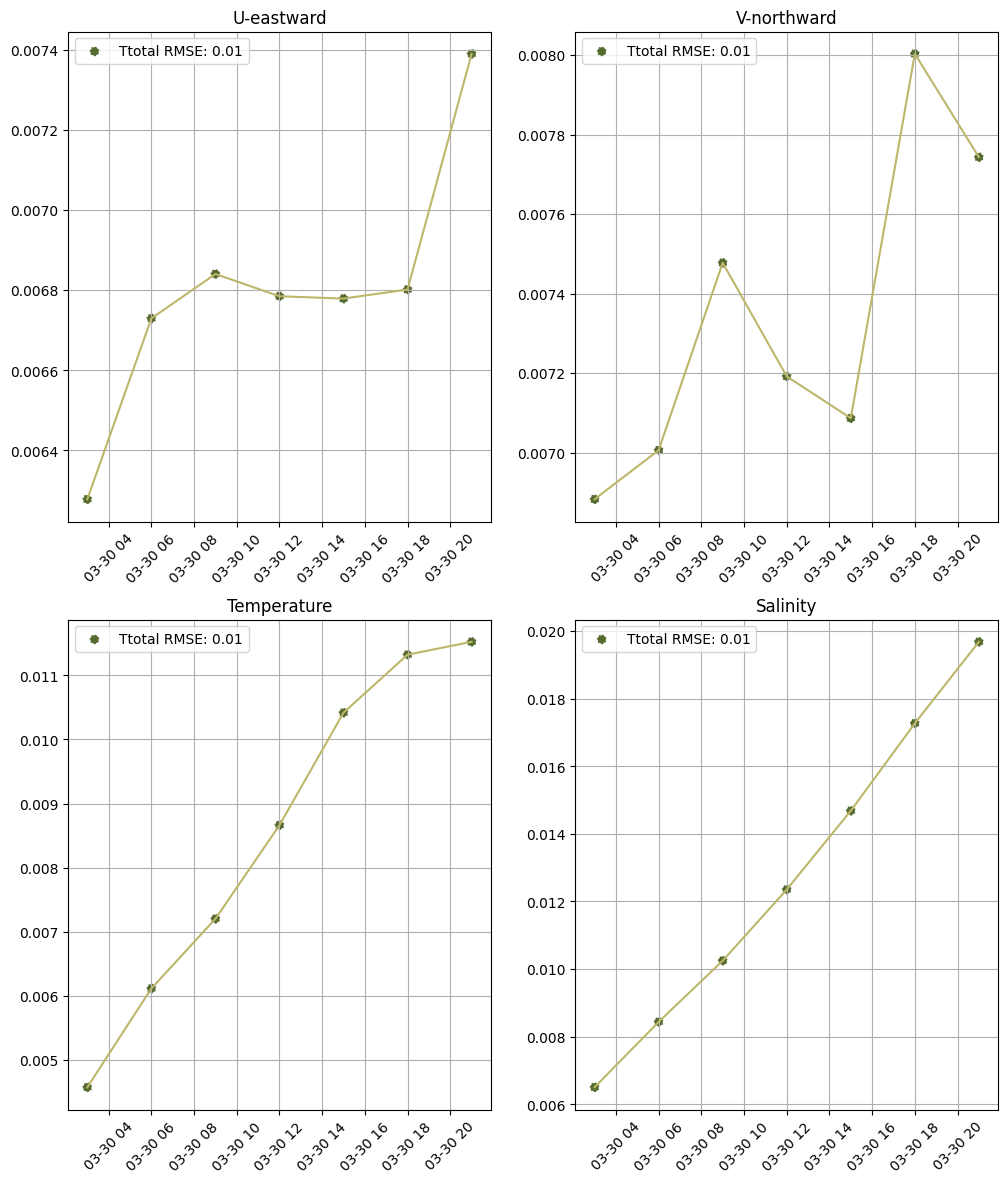

In [6]:
truth = xr.open_dataset('/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240330.nc').isel(s_rho = -1)
predicted = xr.open_dataset('/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42/2024-03-30_24h_18d28_e011_s049990.nc')

#Resample truth datastep 3hrs
truth_resampled = truth.resample(time = '3H').mean()
truth_rename = truth_resampled.rename({'X' : 'Y', 'Y' : 'X'})

#Remove first time step of datasets and align shapes (24hr range)
truth_skip_timestep = truth_rename.isel(time = slice(1,None))
predicted_skip_timestep = predicted.isel(time=slice(1,-1))

#select out variable values - thinking temperature, salinity, u and v
target_vars_norkyst = ['u_eastward', 'v_northward', 'temperature', 'salinity']
target_vars_havbris = ['u_eastward_0', 'v_northward_0', 'temperature_0', 'salinity_0']

normalized_by_timestep = {}
rmse_total = {}
regression_lines = {}

for nk_var, hb_var in zip(target_vars_norkyst, target_vars_havbris):

    nk_data = truth_skip_timestep[nk_var]
    hb_data = predicted_skip_timestep[hb_var]

    #calculating MSE and RMSE using groupby for each timestep
    error = (nk_data - hb_data)
    mse_by_timestep = (error **2).groupby('time').mean(['Y', 'X'])
    rmse_by_timestep = np.sqrt(mse_by_timestep)
    normalized_by_timestep[nk_var] = rmse_by_timestep/(hb_data.max() - hb_data.min())

    #Normalize the RMSE data - a few different methods for this, will try using the diff between maximum and minimum vals 
    #didnt do much - try standard deviation instead of the havbris target

    #std = hb_data.groupby('time').std(dim=['Y','X'])
    #normalized_by_timestep[nk_var] = rmse_by_timestep

    #Also calculate total RMSE for period - will use sklearn for efficient calculation
    #first filter out nans 
    mask = ~np.isnan(nk_data) & ~np.isnan(hb_data)
    rmse_total_before_n = root_mean_squared_error(nk_data.values[mask], hb_data.values[mask])
    rmse_total[nk_var] = rmse_total_before_n / (hb_data.max() - hb_data.min()) 
    #make regression lines for each variable predictions
    nk_reg = nk_data.values[mask].flatten()
    hb_reg = hb_data.values[mask].flatten()

    #for key in nk_var:
        #print(key)

fig, ax = plt.subplots(2,2, figsize = (12,14))

labels = ['U-eastward', 'V-northward', 'Temperature', 'Salinity']
for i, (nk_var, hb_var) in enumerate(zip(target_vars_norkyst, target_vars_havbris)):
    row, col = divmod(i,2)
    ax[row, col].set_title(labels[i])
    ax[row, col].scatter(normalized_by_timestep[nk_var].time, normalized_by_timestep[nk_var], label = 'RMSE per timestep', color = 'darkolivegreen', linestyle = ':')
    ax[row, col].legend([f'Ttotal RMSE: {rmse_total[nk_var]:.2f}'])
    ax[row, col].plot(normalized_by_timestep[nk_var].time, normalized_by_timestep[nk_var], label = 'RMSE per timestep', color = 'darkkhaki', linestyle = '-')
    #ax[row, col].plot(hb_reg, regression_lines[nk_var], color = 'm', label = 'Regression Line')
    plt.setp(ax[row,col].xaxis.get_majorticklabels(), rotation =45)
    ax[row,col].grid(True)
plt.show()


In [4]:
predicted

<xarray.Dataset> Size: 933MB
Dimensions:            (X: 1148, Y: 2747, time: 9)
Coordinates:
  * X                  (X) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
  * Y                  (Y) float64 22kB 0.0 800.0 ... 2.196e+06 2.197e+06
  * time               (time) datetime64[ns] 72B 2024-03-30 ... 2024-03-31
Data variables:
    latitude           (X, Y) float32 13MB ...
    longitude          (X, Y) float32 13MB ...
    salinity_0         (time, X, Y) float32 114MB ...
    temperature_0      (time, X, Y) float32 114MB ...
    u_eastward_0       (time, X, Y) float32 114MB ...
    v_northward_0      (time, X, Y) float32 114MB ...
    h                  (time, X, Y) float32 114MB ...
    sea_mask           (time, X, Y) float32 114MB ...
    f                  (time, X, Y) float32 114MB ...
    river_binary_mask  (time, X, Y) float32 114MB ...

In [16]:
def NRMSE(truth, predict, suptitle):

    #Resample truth datastep 3hrs
    truth_resampled = truth.resample(time = '3H').mean()
    truth_rename = truth_resampled.rename({'X' : 'Y', 'Y' : 'X'})

    #Remove first time step of datasets and align shapes (24hr range)
    truth_skip_timestep = truth_rename.isel(time = slice(1,None))
    predicted_skip_timestep = predict.isel(time=slice(1,-1))

    #select out variable values - thinking temperature, salinity, u and v
    target_vars_norkyst = ['u_eastward', 'v_northward', 'temperature', 'salinity']
    target_vars_havbris = ['u_eastward_0', 'v_northward_0', 'temperature_0', 'salinity_0']

    normalized_by_timestep = {}
    rmse_total = {}

    for nk_var, hb_var in zip(target_vars_norkyst, target_vars_havbris):

        nk_data = truth_skip_timestep[nk_var]
        hb_data = predicted_skip_timestep[hb_var]

        #calculating MSE and RMSE using groupby for each timestep
        error = (nk_data - hb_data)
        mse_by_timestep = (error **2).groupby('time').mean(['Y', 'X'])
        rmse_by_timestep = np.sqrt(mse_by_timestep)
        #normalized_by_timestep[nk_var] = rmse_by_timestep/(hb_data.max() - hb_data.min())

        #Normalize the RMSE data - a few different methods for this, will try using the diff between maximum and minimum vals 
        #not as easy to interpert results because they becmame so similiar - try standard deviation instead

        std = nk_data.groupby('time').std(dim=['Y','X'])
        normalized_by_timestep[nk_var] = rmse_by_timestep / std 

        #Also calculate total RMSE for period - will use sklearn for efficient calculation
        #first filter out nans 
        mask = ~np.isnan(nk_data) & ~np.isnan(hb_data)
        rmse_total_before_n = root_mean_squared_error(nk_data.values[mask], hb_data.values[mask])
        std_total = nk_data.std(dim = ['Y', 'X', 'time']).compute().item()
        rmse_total[nk_var] = rmse_total_before_n / std_total

        #for key in nk_var:
            #print(key)

    fig, ax = plt.subplots(2,2, figsize = (12,14))

    labels = ['U-eastward', 'V-northward', 'Temperature', 'Salinity']
    for i, (nk_var, hb_var) in enumerate(zip(target_vars_norkyst, target_vars_havbris)):
        row, col = divmod(i,2)
        ax[row, col].set_title(labels[i])
        ax[row, col].scatter(normalized_by_timestep[nk_var].time, normalized_by_timestep[nk_var], label = 'RMSE per timestep', color = 'darkolivegreen', linestyle = ':')
        ax[row, col].plot(normalized_by_timestep[nk_var].time, normalized_by_timestep[nk_var], label = 'RMSE per timestep', color = 'darkkhaki', linestyle = '-')
        ax[row, col].axhline(rmse_total[nk_var], color = 'm', linestyle = '--', label = f'Total RMSE: {rmse_total[nk_var]:.2f}')
        plt.setp(ax[row,col].xaxis.get_majorticklabels(), rotation =45)
        ax[row, col].legend()
        ax[row,col].grid(True)
    plt.suptitle(f'{suptitle}')
    plt.show()
    


In [17]:
seven_days_24hr_lead_norkyst = xr.open_mfdataset(['/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240330.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240331.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240401.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240402.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240403.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240404.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240405.nc']).isel(s_rho=-1)

In [10]:
seven_days_2hr_lead_havbris = xr.open_mfdataset(['/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42/2024-03-30_24h_18d28_e011_s049990.nc', '/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42/2024-03-31_24h_18d28_e011_s049990.nc', '/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42/2024-04-01_24h_18d28_e011_s049990.nc', '/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42/2024-04-02_24h_18d28_e011_s049990.nc', '/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42/2024-04-03_24h_18d28_e011_s049990.nc', '/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42/2024-04-04_24h_18d28_e011_s049990.nc', '/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42/2024-04-05_24h_18d28_e011_s049990.nc'])

In [14]:
seven_days_24hr_lead_norkyst_d = seven_days_24hr_lead_norkyst.drop_duplicates(dim = ['X', 'Y', 'time'])
seven_days_2hr_lead_havbris_d = seven_days_2hr_lead_havbris.drop_duplicates(dim = ['X', 'Y', 'time'])

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


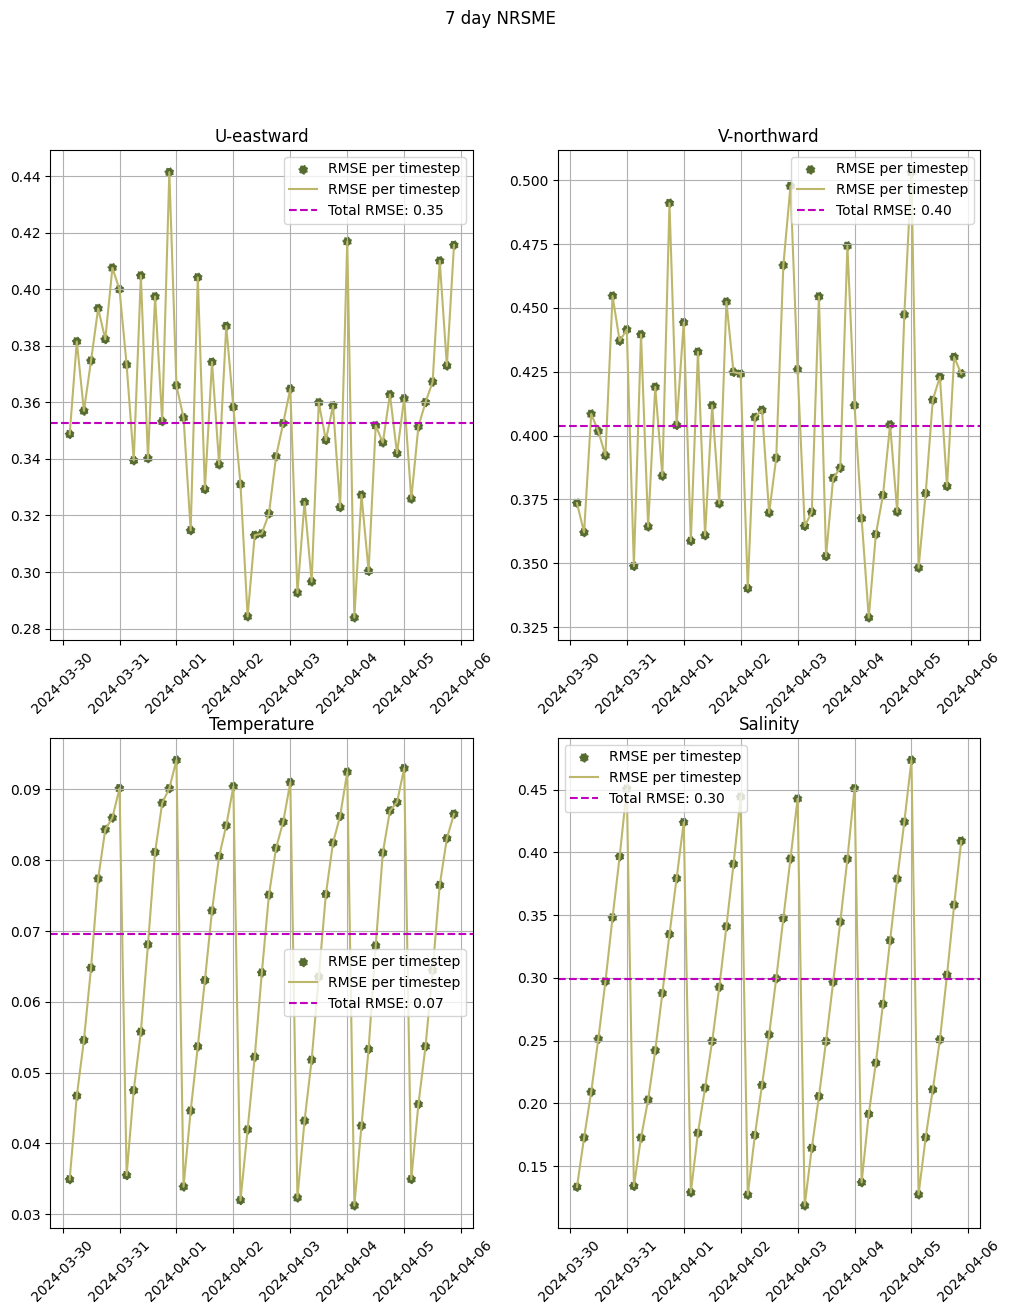

In [18]:
NRMSE(seven_days_24hr_lead_norkyst_d, seven_days_2hr_lead_havbris_d, '7 day NRSME')

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


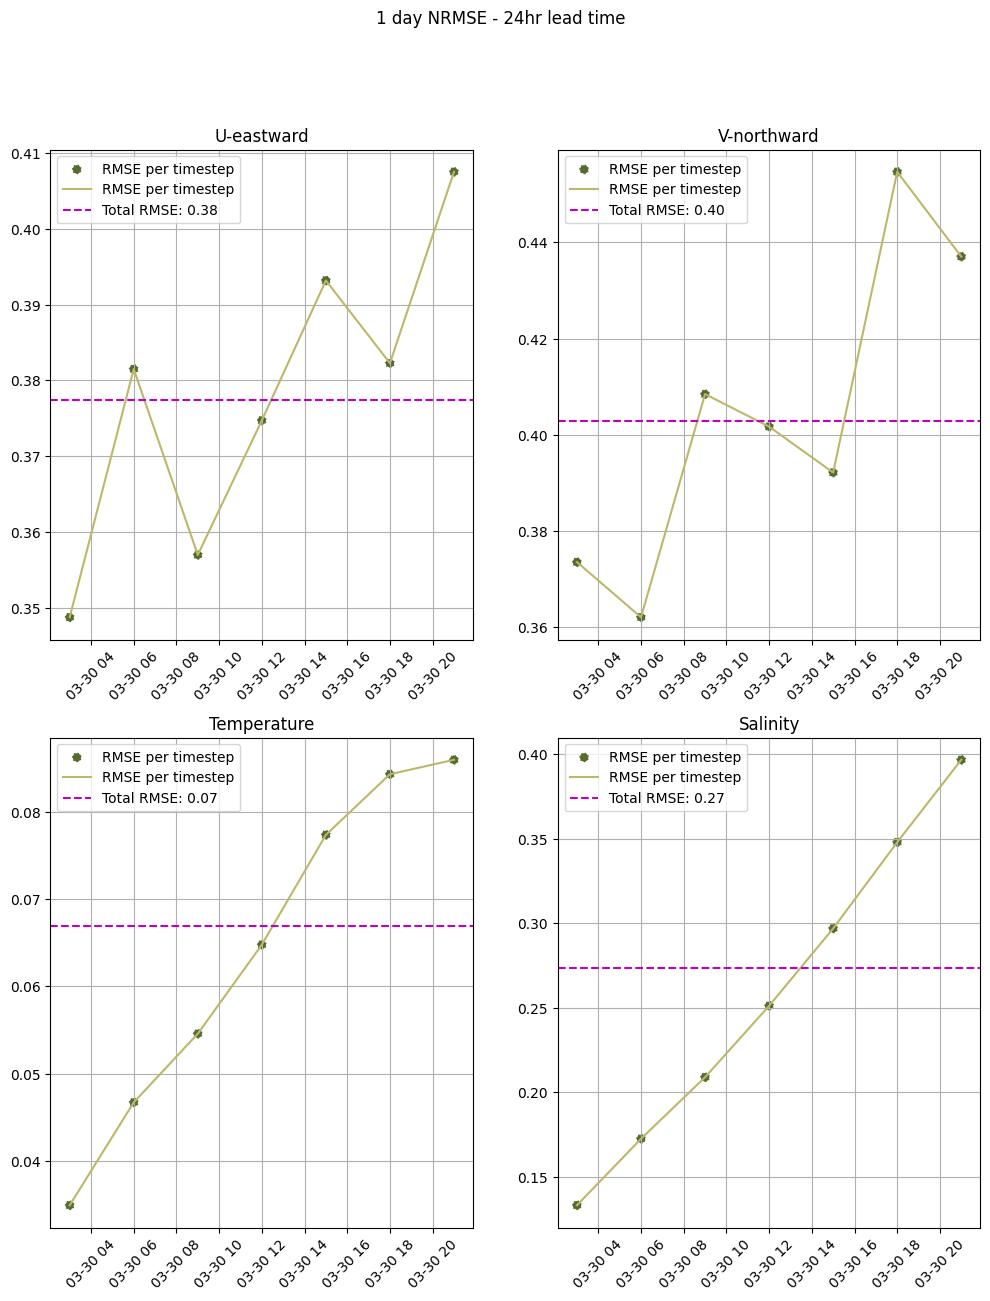

In [19]:
NRMSE(truth = truth, predict = predicted, suptitle='1 day NRMSE - 24hr lead time')

In [22]:
#Test for 48hr lead time 

two_days_48_lead_havbris = xr.open_dataset('/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/lr_v2/lr3-5e-04-st200-se42/2024-03-30_48h_18d28_e011_s049990.nc')

In [21]:
norkyst_two_days = xr.open_mfdataset(['/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240330.nc', '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240331.nc']).isel(s_rho = -1)
norkyst_two_days_d = norkyst_two_days.drop_duplicates(dim = ['X', 'Y', 'time'])


/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/xarray/groupers.py:487: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


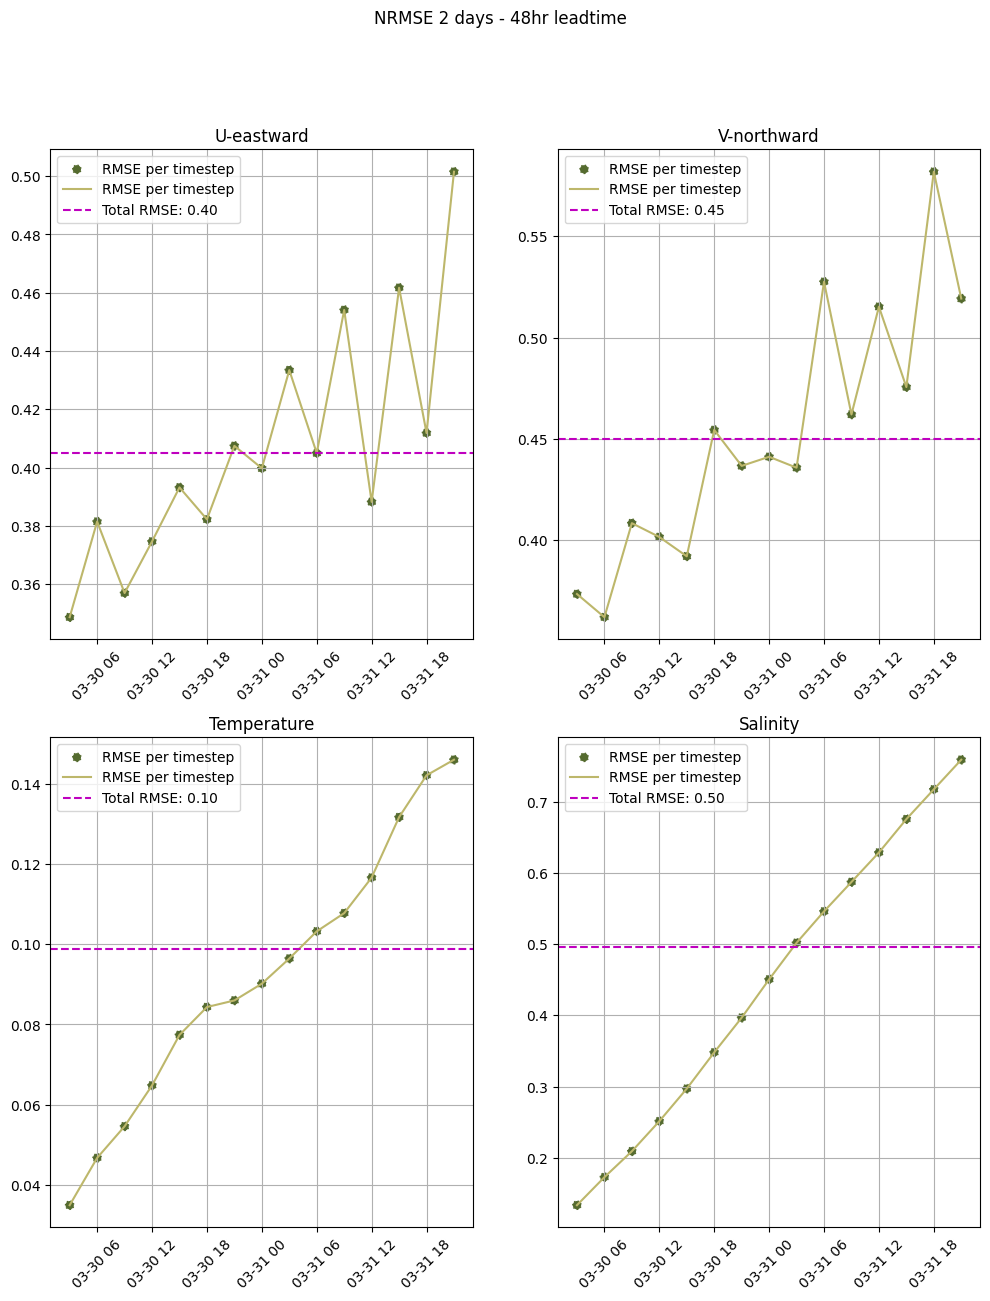

In [23]:
NRMSE(norkyst_two_days_d, two_days_48_lead_havbris, 'NRMSE 2 days - 48hr leadtime')